<a href="https://colab.research.google.com/github/vishnuvardhan1699/2520030392_ML/blob/main/Practical/week%2010/KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

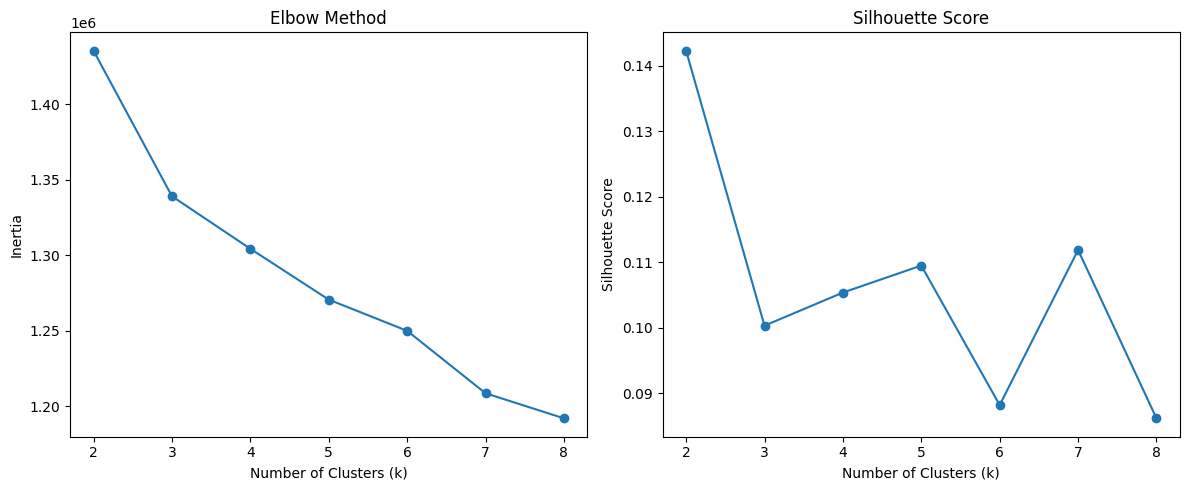

Best k: 2
K-Means Silhouette Score: 0.142
Cluster Sizes:
0    18110
1    31890
Name: count, dtype: int64
K-Means completed successfully.


In [2]:
# KMeans.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

NUMERIC_COLS = [
    "CGPA", "AttendancePercent", "Internships", "Projects", "Workshops",
    "Certifications", "Publications", "AptitudeTestScore",
    "SoftSkillsRating", "CodingTestScore", "MockInterviewScore"
]

CATEGORICAL_COLS = [
    "Gender", "City", "CollegeTier", "Stream", "Specialisation",
    "Hostel", "HistoryOfBacklogs", "ExtraCurricular"
]

df = pd.read_csv("/content/placement_predict_50k Dataset (1).csv")

imputer = SimpleImputer(strategy="median")

num_df = pd.DataFrame(
    imputer.fit_transform(df[NUMERIC_COLS]),
    columns=NUMERIC_COLS
)

cat_df = pd.get_dummies(df[CATEGORICAL_COLS], drop_first=True)

feature_df = pd.concat([num_df, cat_df], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

k_range = range(2, 9)

sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X), 5000, replace=False
)

X_sample = X[sample_idx]

inertias = []
silhouette_scores = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )

    labels = model.fit_predict(X)

    inertias.append(model.inertia_)

    silhouette_scores.append(
        silhouette_score(
            X_sample,
            model.predict(X_sample)
        )
    )

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.subplot(1, 2, 2)
plt.plot(list(k_range), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.tight_layout()
plt.savefig("kmeans_elbow_silhouette.png")
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]

print("Best k:", best_k)

kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=RANDOM_STATE
)

labels = kmeans.fit_predict(X)

score = silhouette_score(
    X_sample,
    kmeans.predict(X_sample)
)

print("K-Means Silhouette Score:", round(score, 3))
print("Cluster Sizes:")
print(pd.Series(labels).value_counts().sort_index())

df["KMeansCluster"] = labels

df.to_csv(
    "kmeans_clustered_data.csv",
    index=False
)

print("K-Means completed successfully.")